## Geometric Brownian Motion - GBM
It is generally assumed/accepted/known that **equity prices are log-normally distributed,** __and__ **the log difference in prices are normally distributed.** From logarithmic properties we know that difference of the logs is the same as log of the quotient. Therefore log difference or log return between price at now and price at a period later is proportional to price at now. Because the log returns are normally distributed they can be modeled by, two parameters, average and standard deviation of the returns but not exactly.

#### We arrive at this Stochastic Differential Equation (SDE) that models the properties from above. Bellow are some of the ways it's written:
$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t = S_t(\mu dt + \sigma dW_t)$$
$$\frac{dS_t}{S_t} =  \mu dt + \sigma dW_t$$

#### Solving the SDE allows us to simulate/generate ex-post/future prices based on expected average annual returns a.k.a **drift** and volatility(annualized standard deviation). Historical average and standard deviation of the log returns may be used as expected future parameters(Yes, it's debatable).
However, annualized average returns is not a direct drop in for $\mu$ instead it is adjusted. To understand the adjustment take a 10% and 20% up and down round trip from 100. 
$100\cdot(1 + 0.1)\cdot(1 - 0.1) = 99$ and also $100\cdot(1 + 0.2)\cdot(1 - 0.2) = 96$. This proves that **asset prices suffer a drag effect induced by volatility and that it has a squared effect.** Therefore, adjusted drift $\mu - \frac{\sigma^2}{2}$

#### In general form; every future price can be modeled proportionally from the previous state with this equation
$$ln(S_{T+1}) = ln(S_T) + \displaystyle \int_{0}^t(\mu - \frac{\sigma^2}{2})dt + \displaystyle \int_{0}^t \sigma dW(t)$$
$$e^{ln(S_{T+1})} = e^{ln(S_T) + \displaystyle \int_{0}^t(\mu- \frac{\sigma^2}{2})dt + \displaystyle \int_{0}^t \sigma dW(t)}$$
$$e^{ln(S_{T+1})} = e^{ln(S_T)} \cdot e^{\displaystyle \int_{0}^t(\mu - \frac{\sigma^2}{2})dt + \displaystyle \int_{0}^t \sigma dW(t)}$$
$$S_{T+1} = S_T \cdot e^{\displaystyle \int_{0}^t(\mu - \frac{\sigma^2}{2})dt + \displaystyle \int_{0}^t \sigma dW(t)}$$

#### For simulation, there is a discretization approach to approximate the continuous SDE:
$$S_{t+1} = S_{t} \times e^{(\mu - \frac{1}{2} \sigma^2) \Delta t + \sigma \sqrt{\Delta t} Z}$$

#### Where:
 - $S_{t+1}$ and $S_{t}$ is the asset price at time t+1 and t respectively
 - $\mu$ is the drift
 - $\sigma$ is the volatility
 - $dt$ is the time between two prices states 
 - dW_t is a Wiener process that mimics physical Brownian motion. This is the part that generates vibration/increments per $dt$ that are normally distributed


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
pd.options.display.float_format = '{:.2f}'.format

In [2]:
stock = pd.read_csv("../../../data/SPY.Daily.csv")
stock['ret'] = stock.close.pct_change()

## Initialize Parameters

In [3]:
num_paths = 1000
num_days = 252
initial_price = stock.close.loc[stock.shape[0]-1]
# dt = 1/(num_days*2) #If we increase granularity between two days
dt = 1/(num_days)
daily_returns = stock['ret'].mean()  # Daily Mean
daily_stdev   = stock['ret'].std()   # Daily standard deviation

#Annulized 
annualized_returns = daily_returns * num_days #Annualized Mean
volatility = daily_stdev * np.sqrt(num_days)  #Annualized Stdev aka Volatility
drift = (annualized_returns - 0.5 * volatility**2)*dt # Annual drift

## Generate random numbers for the simulation

In [4]:
# random_values = np.random.standard_normal((num_days*2, num_paths)) #If we increase the number of path between two periods
random_values = np.random.standard_normal((num_days, num_paths)) #Scaled normal distribution
print(random_values.shape)

(252, 1000)


## Simulation sequentially

In [5]:
price_paths = np.zeros((num_days, num_paths))
price_paths[0] = initial_price
for t in range(1, num_days):
    price_paths[t] = price_paths[t-1] * np.exp(drift + volatility * random_values[t] * np.sqrt(dt))
price_paths = pd.DataFrame(price_paths)
price_paths['Mean'] = price_paths.mean(axis=1)
price_paths['Median'] = price_paths.median(axis=1)

## Generate Price Path - Vectorize

In [7]:
price_paths = np.exp(drift + volatility * random_values * np.sqrt(dt)) #vectorise (1+ mu + Z*sigma). Based on scaled normal
price_paths[0] = initial_price #Set initial value at the head of each simulation
price_paths = price_paths.cumprod(axis=0)
price_paths = pd.DataFrame(price_paths)
price_paths['Mean'] = price_paths.mean(axis=1)
price_paths['Median'] = price_paths.median(axis=1)

## Plot Simulation

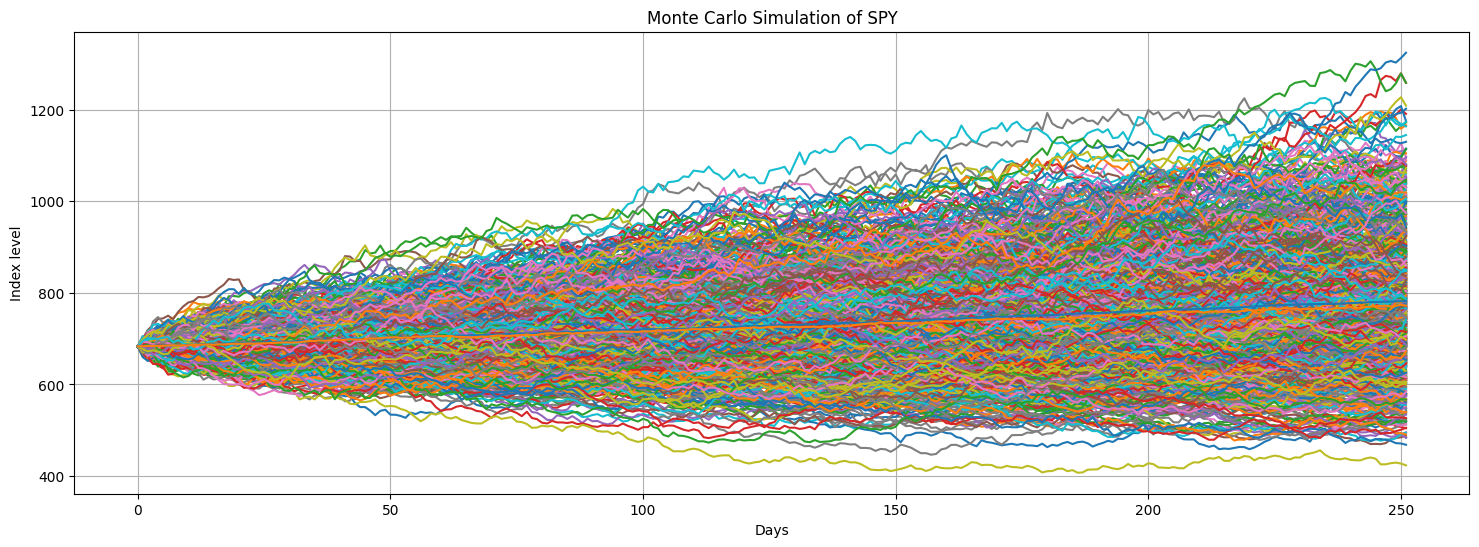

In [8]:
plt.figure(figsize=(18, 6))
plt.plot(price_paths)
plt.title(f'Monte Carlo Simulation of SPY')
plt.xlabel('Days')
plt.ylabel('Index level')
plt.grid(True)

## Histogram of the terminal values(last day) of the simulation

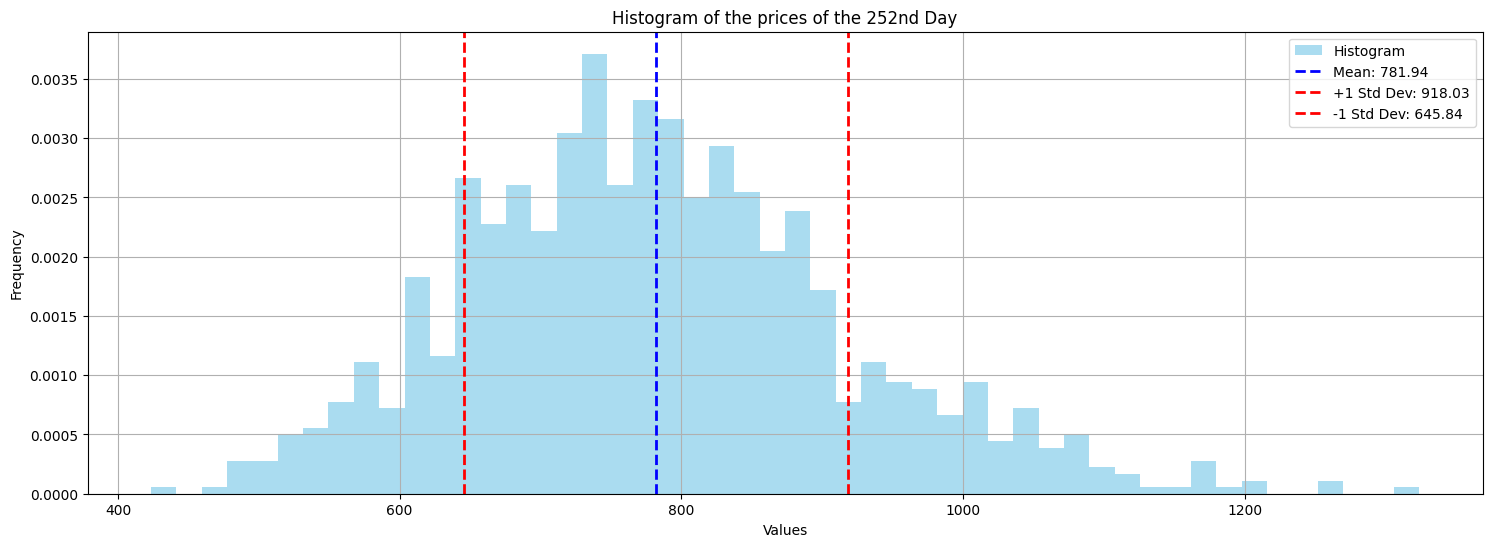

In [9]:
mean_val = price_paths.loc[251,:].mean() #Mean or average of the prices on the 252nd day
std_val = price_paths.loc[251,:].std()   #STDEV or average of the prices on the 252nd day
plt.figure(figsize=(18, 6))
plt.hist(price_paths.loc[251], bins=50, color='skyblue', alpha=0.7, label='Histogram', density=True)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(True)
plt.title("Histogram of the prices of the 252nd Day")
plt.axvline(mean_val, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(mean_val + std_val, color='red', linestyle='dashed', linewidth=2, label=f'+1 Std Dev: {mean_val + std_val:.2f}')
plt.axvline(mean_val - std_val, color='red', linestyle='dashed', linewidth=2, label=f'-1 Std Dev: {mean_val - std_val:.2f}')
plt.legend()

### Conclusion:
- It can be argued that this method is best for index/ETF like instruments
- Mean and Standard deviation is assumed to be constant through out the generative path
- Unable to model structural breaks or sudden jumps such as due to earnings surprises on individual stocks